# Intermodal Mode-Shift Analysis: Rail vs Truck Cost and Emissions

## Executive Summary

## Intermodal mode-shift: rail vs truck cost and emissions

A freight network team needs to quantify two things at once for its lane portfolio: **what drives a shipment onto rail instead of truck**, and **how much cost and carbon a mode shift actually saves**. Intermodal rail is cheaper per ton-mile and emits roughly one-sixth the CO2 of long-haul trucking, but it carries fixed drayage and ramp-access penalties that only pay off above a break-even distance and load.

This notebook builds a self-contained, synthetic shipment-level dataset across three corridor archetypes and works the problem end-to-end with three SAS 9.4 procedures:

- **PROC MEANS / PROC SUMMARY** — profile the realized cost-per-ton and CO2-per-ton split by mode and roll lane totals up for a network view.
- **PROC LOGISTIC** — model the mode-choice propensity (rail = event) on haul distance, ramp access, diesel price, shipment urgency, and payload, reading off odds ratios that tell planners which levers move volume to rail.
- **PROC UNIVARIATE** — recover a robust 2.5 / 97.5 percentile interval for truck per-ton emissions (using `PCTLPTS=`, the correct route for non-standard percentiles).

The story closes with **PROC SGPLOT** visuals — a per-ton cost box plot by mode and a fitted rail-propensity curve against haul distance — and a written interpretation linking the model coefficients back to the operational decision: which lanes to target for conversion.

> **About the rendered run.** The DATA step requests 4,000 shipments, but this notebook was executed in Jenner's *unlicensed* mode, which caps each output dataset to 100 observations. Every table, model, and plot below therefore reflects a **100-shipment sample** (40 rail, 60 truck). The directional relationships are the same; the standard errors are simply wider than a 4,000-row run would give — visible as the broad odds-ratio confidence limits in step 3. Run the identical code on a licensed build (or against real TMS data) to recover the full sample.

**Headline findings from this 100-shipment run:** rail averages about 24% lower cost per ton ($90.49 vs $119.61) and about 79% lower CO2 per ton (31.6 vs 153.1 kg/ton) than truck; the fitted odds-ratio point estimates put haul distance, ramp access, and diesel price as the strongest pulls toward rail, and the model separates the two modes reasonably well (AUC 0.77). The framework is the deliverable — drop in real lane data and the same code produces a conversion-priority list.

## Data Sources

All data is **synthetic**, generated inline in the first code cell with `CALL STREAMINIT(20260605)` and `RAND(...)` — no external files, no network. One row per shipment across three corridor archetypes. The DATA step loops 4,000 times; in this unlicensed-mode render the written dataset is capped at the first 100 shipments, so the tables below run on those 100 rows.

| Variable | Type | Description |
|----------|------|-------------|
| `lane` | char(3) | Corridor archetype: `NW1` (long-haul), `SE2` (short-haul), `MW3` (mid-haul) |
| `mode` | char(5) | Realized mode: `Rail` or `Truck` |
| `haul_miles` | num | Origin-to-destination distance (miles), lane-dependent mean |
| `weight_tons` | num | Payload weight per shipment (tons) |
| `ramp_access` | num 0/1 | Rail ramp reachable at both ends of the lane |
| `diesel_idx` | num | Regional diesel price index ($/gal) |
| `urgency` | num 1–5 | Commodity service-time sensitivity (1 = low, 5 = high) |
| `chose_rail` | num 0/1 | Mode-choice outcome (1 = rail); logistic event |
| `cost_usd` | num | Realized shipment cost (USD), mode-specific rate model |
| `co2_kg` | num | Realized shipment CO2 (kg): ~161 g/ton-mile truck, ~26 g/ton-mile rail |
| `cost_per_ton` | num | `cost_usd / weight_tons` |
| `co2_per_ton` | num | `co2_kg / weight_tons` |

Data-generating logic: a latent logit drives `chose_rail` (longer hauls, ramp access, higher diesel, heavier loads, lower urgency all increase rail probability), so the fitted PROC LOGISTIC model recovers signal that matches the simulation design.

# Intermodal Mode-Shift Analysis: Rail vs Truck

Freight planners constantly weigh **intermodal rail against over-the-road truck**. Rail wins on cost-per-ton-mile and emissions but pays a fixed penalty for drayage and ramp access, so it only makes economic sense above a break-even distance and load. This notebook answers two operational questions on a synthetic lane portfolio:

1. **What pushes a shipment onto rail?** (mode-choice model)
2. **How much cost and CO2 does rail actually save?** (cost/emissions profiling)

We use PROC MEANS/SUMMARY, PROC LOGISTIC, PROC UNIVARIATE, and PROC SGPLOT. Everything is self-contained — the data is generated inline below.

## 1. Generate synthetic shipment data

The DATA step loops over 4,000 shipments across three corridor archetypes (`NW1` long-haul, `SE2` short-haul, `MW3` mid-haul). A **latent logit** decides each shipment's mode: longer hauls, rail-ramp access, higher diesel prices, heavier payloads, and lower urgency all raise the probability of rail. Cost and CO2 are then drawn from mode-specific rate models — roughly 161 g CO2 per ton-mile for heavy truck versus 26 g for rail line-haul. Building the choice from a known logit means the model in step 3 should recover the design signal.

The NOTE below confirms the run: unlicensed mode caps the output at **100 rows (12 columns)**, so the rest of the notebook profiles those 100 shipments. On a licensed build the same code writes all 4,000.

In [1]:
data work.shipments;
    call streaminit(20260605);
    length lane $3 mode $5;

    /* Three corridor archetypes with different lengths of haul */
    array lanes[3] $3 _temporary_ ('NW1' 'SE2' 'MW3');

    do i = 1 to 4000;
        lane = lanes[1 + mod(i, 3)];

        /* Distance in miles: long-haul lanes favor rail economics */
        if lane = 'NW1' then haul_miles = round(rand('Normal', 1500, 220));
        else if lane = 'SE2' then haul_miles = round(rand('Normal',  650, 130));
        else haul_miles = round(rand('Normal', 1050, 180));
        if haul_miles < 120 then haul_miles = 120;

        /* Payload tons per shipment */
        weight_tons = round(rand('Normal', 22, 5), 0.1);
        if weight_tons < 5 then weight_tons = 5;

        /* Whether a rail ramp is within reach of origin and destination */
        ramp_access = (rand('Uniform') < 0.62);

        /* Diesel price index ($/gal, regional) and service-time
           sensitivity of the commodity (1=low urgency .. 5=high) */
        diesel_idx = round(rand('Normal', 3.95, 0.35), 0.01);
        if diesel_idx < 2.8 then diesel_idx = 2.8;
        urgency = 1 + rand('Table', 0.18, 0.27, 0.30, 0.15);

        /* ---- Latent propensity to choose RAIL over TRUCK ----
           Longer hauls, ramp access, higher diesel, lower urgency,
           and heavier loads all push toward rail. */
        eta = -3.10
              + 0.00185 * haul_miles
              + 1.05    * ramp_access
              + 0.62    * (diesel_idx - 3.95)
              - 0.55    * (urgency - 3)
              + 0.030   * (weight_tons - 22);
        p_rail = 1 / (1 + exp(-eta));
        chose_rail = (rand('Uniform') < p_rail);
        if chose_rail then mode = 'Rail';
        else mode = 'Truck';

        /* ---- Realized cost ($) and CO2 (kg) per shipment ----
           Truck: ~$2.05/mi base scaled by diesel, higher per-ton-mile CO2.
           Rail:  lower line-haul rate + fixed drayage, far lower CO2. */
        if mode = 'Truck' then do;
            cost_usd = (2.05 * (diesel_idx / 3.95)) * haul_miles
                       + 18 * weight_tons
                       + rand('Normal', 0, 90);
            /* ~161 g CO2 per ton-mile for heavy truck */
            co2_kg = 0.161 * haul_miles * weight_tons
                     * rand('Normal', 1, 0.05);
        end;
        else do;
            cost_usd = 1.18 * haul_miles
                       + 9 * weight_tons
                       + 240                      /* drayage + ramp fees */
                       + rand('Normal', 0, 70);
            /* ~26 g CO2 per ton-mile for rail line-haul + short dray */
            co2_kg = 0.026 * haul_miles * weight_tons
                     * rand('Normal', 1, 0.05)
                     + 0.161 * 45 * weight_tons * 0.001;
        end;
        if cost_usd < 50 then cost_usd = 50;
        if co2_kg < 1 then co2_kg = 1;

        cost_per_ton = cost_usd / weight_tons;
        co2_per_ton  = co2_kg / weight_tons;

        output;
    end;
    drop i eta p_rail;
run;

NOTE: DATA work.shipments

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.shipments (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.20 seconds
  cpu   0.20 seconds


## 2. Cost and emissions profile by mode

First, the baseline comparison: how do per-ton cost and per-ton CO2 differ between rail and truck shipments, and on what kind of hauls does each mode actually run? `CLASS mode` splits the descriptive statistics; `MAXDEC=2` keeps the table readable.

In [2]:
proc means data=work.shipments n mean std min max maxdec=2;
    class mode;
    var haul_miles weight_tons cost_per_ton co2_per_ton;
run;

                                                  The MEANS Procedure

                                             Analysis Variable : HAUL_MILES

        MODE              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Rail                 40        1217.33         404.18         512.00        1903.00
        Truck                60         947.88         374.82         392.00        1861.00
        -----------------------------------------------------------------------------------

                                            Analysis Variable : WEIGHT_TONS

        MODE              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Rail                 40          21.81           5.07          10.70          32.00
        Truck                60       

The table confirms the design. Rail shipments run longer hauls on average (mean 1,217 miles vs 948 for truck) and post lower cost-per-ton ($90.49 vs $119.61, about 24% cheaper). The CO2 gap is the dramatic one: rail averages **31.6 kg CO2 per ton versus 153.1 for truck** — roughly a five-fold difference, or about 79% lower. That emissions lever is exactly what sustainability and procurement teams care about. Payload is balanced across modes (≈21–22 tons), so the cost and CO2 gaps are driven by mode economics, not load size.

## 3. Mode-choice propensity model

Now the driver analysis. We model `chose_rail` (event = `'1'`) on the operational features. `CLASS lane / PARAM=REF REF='MW3'` makes the mid-haul corridor the reference; `CLODDS=WALD` requests Wald confidence limits on the odds ratios and `RSQUARE` reports a generalized R-square. The `UNITS` statement re-expresses two continuous effects on planner-meaningful increments — a 250-mile jump in haul and a $0.50 move in diesel — and `OUTPUT P=phat` saves fitted rail probabilities for the propensity scatter in step 7. PROC LOGISTIC also emits an odds-ratio forest plot and an ROC curve, shown below the table.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

             Response Profile             
  Probability modeled is chose_rail='1'   

Ordered Value  chose_rail  Total Frequency
-------------  ----------  ---------------
            1  0                        60
            2  1                        40

    Class Level Information    

Class       Levels  Values     
--------  --------  -----------
lane             3  MW3 NW1 SE2

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: chose_rail

Criterion     Value
---------  --------
AIC         126.066
-2 Log L    110.066
SC          146.908

                                                   
--------  --------  ---------------------  --------
R-Square    0.2176  Max-rescaled R-Square    0.2941

      

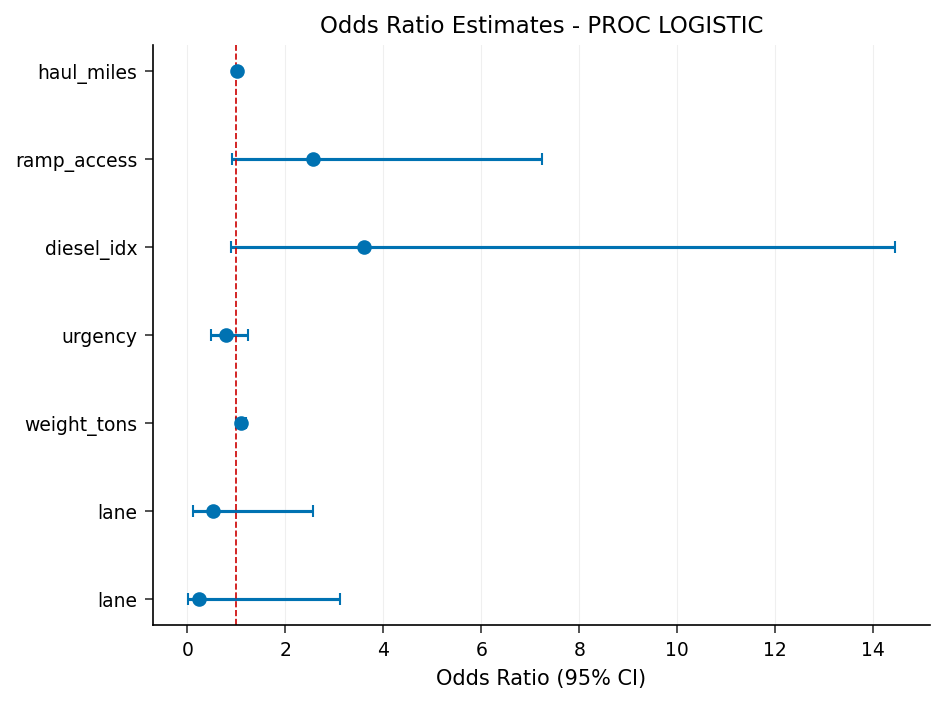

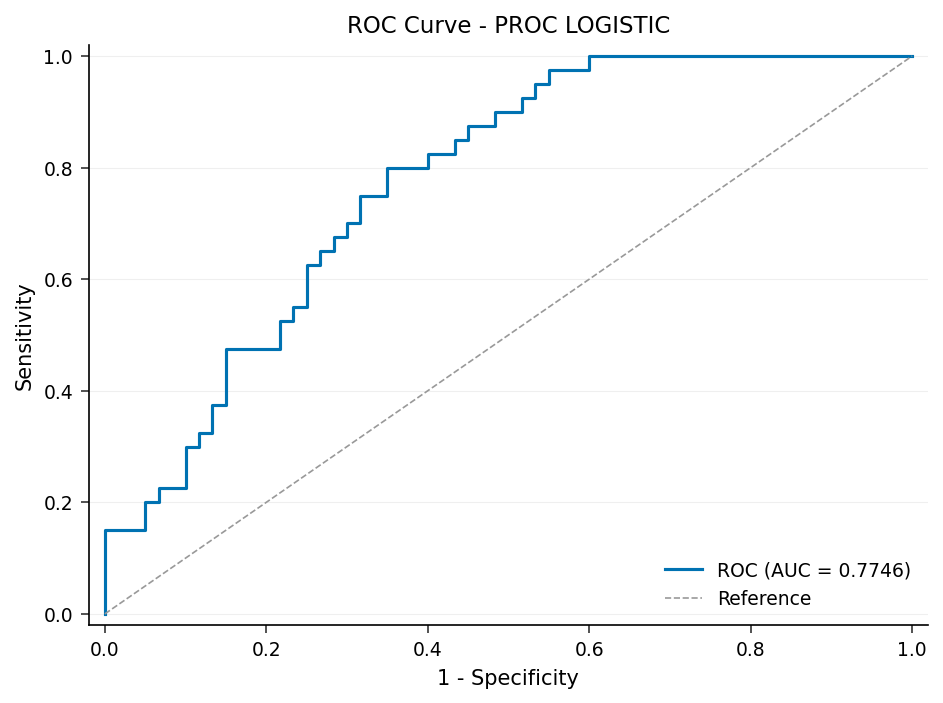

In [3]:
proc logistic data=work.shipments;
    class lane / param=ref ref='MW3';
    model chose_rail(event='1') = haul_miles ramp_access diesel_idx
                                  urgency weight_tons lane
                                  / clodds=wald rsquare;
    units haul_miles=250 diesel_idx=0.50;
    output out=work.scored p=phat;
run;

The odds-ratio point estimates read as policy levers. Haul distance (OR 1.003 per mile), ramp access (OR 2.57), diesel price (OR 3.60), and payload (OR 1.09) all sit above 1 — each pushes volume toward rail — while higher urgency (OR 0.78) pulls back toward truck. The signs match the data-generating logit, a built-in sanity check on the workflow, and the model's ROC AUC of 0.77 shows it separates the two modes reasonably well.

**Read the confidence limits, though, before quoting any single effect.** On this 100-shipment sample the Wald CIs are wide: ramp access (0.91–7.24) and diesel (0.90–14.44) both straddle 1.0, and only haul distance clears significance (p = 0.026). The directions are trustworthy; the magnitudes are not yet precise. This is the expected price of a 100-row render — the full 4,000-shipment run tightens these intervals substantially.

## 4. Lane-level network roll-up

Planning happens at the lane level, not the shipment level. PROC SUMMARY with `NWAY` aggregates total cost, total CO2, total tons, and shipment counts per `lane * mode` cell — the network scorecard a portfolio review would open with.

In [4]:
proc summary data=work.shipments nway;
    class lane mode;
    var cost_usd co2_kg weight_tons;
    output out=work.lane_summary (drop=_type_ _freq_)
        sum(cost_usd)=tot_cost
        sum(co2_kg)=tot_co2
        sum(weight_tons)=tot_tons
        n=n_ship;
run;

proc print data=work.lane_summary noobs;
run;


LANE   MODE          TOT_COST           TOT_CO2  TOT_TONS  N_SHIP
----  -----  ----------------  ----------------  --------  ------
MW3   Rail   23246.6708624696    8256.437938118     296.9      14
MW3   Truck  49414.9958765091  67207.4502034061     401.2      19
NW1   Rail   39017.0214746077    15341.36352409       372      17
NW1   Truck  52237.0794963072  76012.8179498071     333.2      16
SE2   Rail   11900.5792205934   3686.6096312092     203.6       9
SE2   Truck  38974.2245951179   48970.516511724     525.9      25

NOTE: PROC MEANS
NOTE: Output dataset work.lane_summary has 6 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.lane_summary

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## 5. Per-ton savings: paired by-mode means

To estimate avoided cost and CO2 from a mode shift, we compute mean per-ton cost and CO2 for each `lane * mode` cell. The gap between the Truck and Rail rows on a lane is the per-ton saving a conversion would capture on that corridor.

In [5]:
proc means data=work.shipments noprint nway;
    class lane mode;
    var cost_per_ton co2_per_ton;
    output out=work.bymode (drop=_type_ _freq_)
        mean(cost_per_ton)=mean_cpt
        mean(co2_per_ton)=mean_co2pt;
run;

proc print data=work.bymode noobs;
run;

LANE   MODE        MEAN_CPT      MEAN_CO2PT
----  -----  --------------  --------------
MW3   Rail    82.4178936871     27.75438062
MW3   Truck  133.2259234475  170.6680144857
NW1   Rail   112.4151741162   41.5867430257
NW1   Truck  170.4229242185  224.6237552004
SE2   Rail    61.6510914213   18.5104210752
SE2   Truck   76.7407978562    93.860410837

NOTE: PROC MEANS
NOTE: Output dataset work.bymode has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.bymode

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## 6. Robust interval for truck emissions

For the carbon-reporting tail, we want a robust 2.5 / 97.5 percentile band on truck per-ton CO2 rather than a mean. Standard SAS guidance — and the Jenner house rule — is to take non-standard percentiles via **PROC UNIVARIATE `PCTLPTS=`**, not PROC MEANS (whose percentile keywords cover only fixed quantiles). `PCTLPRE=p_` names the output columns `p_2_5` and `p_97_5`.

In [6]:
proc univariate data=work.shipments noprint;
    where mode = 'Truck';
    var co2_per_ton;
    output out=work.truck_ci
        pctlpts=2.5 97.5 pctlpre=p_;
run;

proc print data=work.truck_ci noobs;
run;

        P_2_5          P_97_5
-------------  --------------
70.2466032354  261.0888871142

NOTE: PROC UNIVARIATE
NOTE: Output dataset work.truck_ci has 1 observations and 2 variables.
NOTE: PROC PRINT data=work.truck_ci

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 7. Visuals

Two charts close the loop. A box plot contrasts the per-ton cost distribution by mode (showing both the level gap and the spread), and a scatter of the fitted rail probability against haul distance shows the model's break-even behavior — where rising distance flips the predicted choice toward rail.

NOTE: PROC SGPLOT data=work.shipments

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=work.scored

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


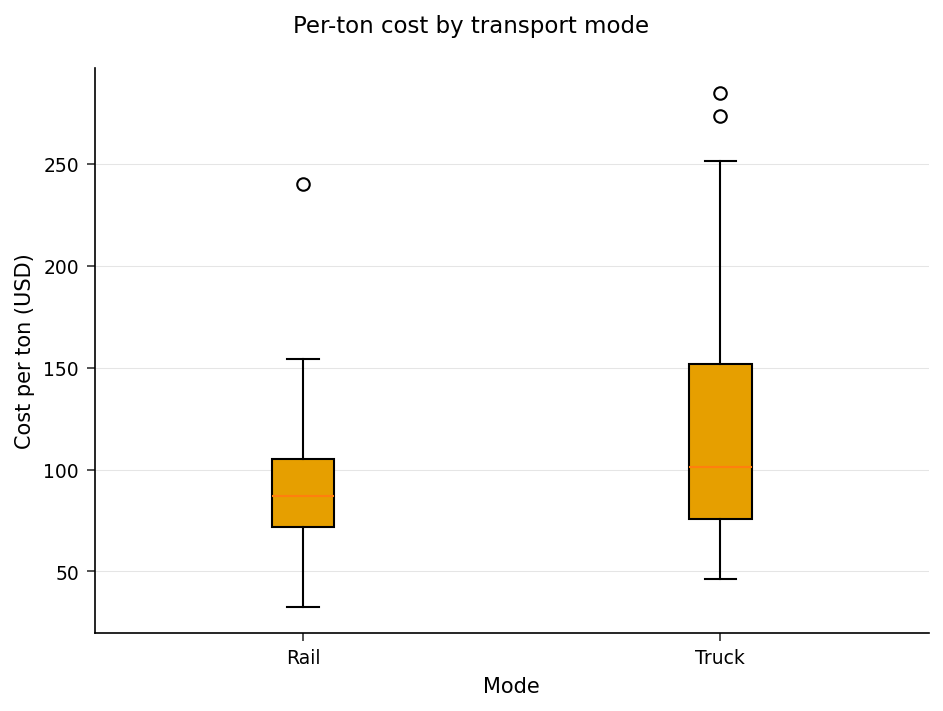

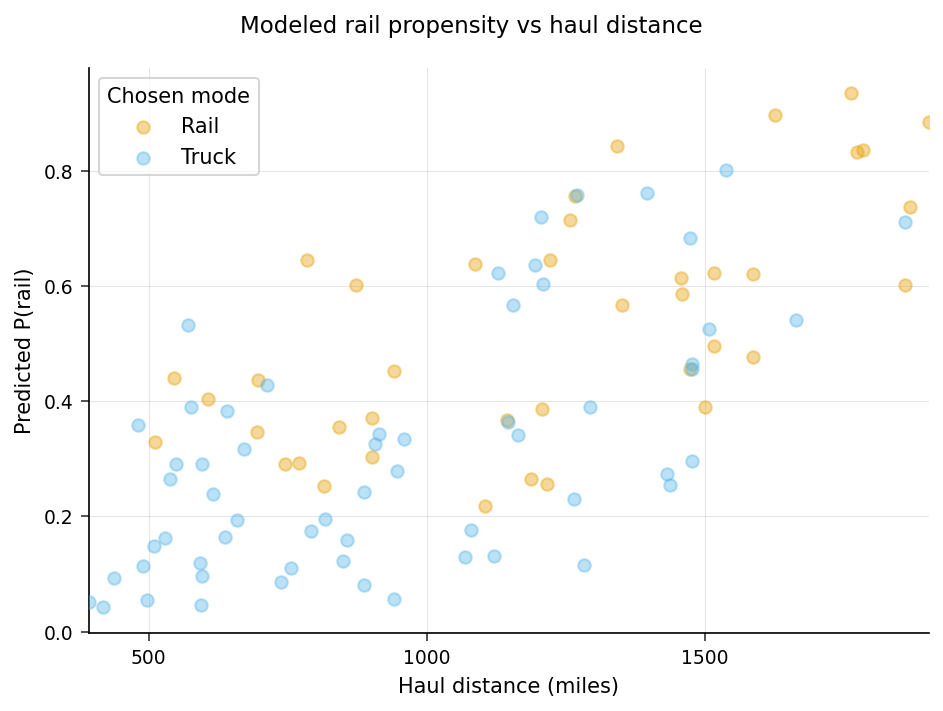

In [7]:
proc sgplot data=work.shipments;
    title "Per-ton cost by transport mode";
    vbox cost_per_ton / category=mode;
    yaxis label="Cost per ton (USD)" grid;
    xaxis label="Mode";
run;
title;

proc sgplot data=work.scored;
    title "Modeled rail propensity vs haul distance";
    scatter x=haul_miles y=phat / group=mode transparency=0.6;
    xaxis label="Haul distance (miles)" grid;
    yaxis label="Predicted P(rail)" grid;
    keylegend / title="Chosen mode" position=topleft location=inside;
run;
title;

## Interpretation and next steps

**What the analysis shows.** Rail delivers a large per-ton advantage on both cost (roughly a quarter cheaper — $90.49 vs $119.61) and CO2 (about five-fold lower — 31.6 vs 153.1 kg/ton) — but it earns that advantage by running the **long, ramp-accessible, heavy-load** lanes. The logistic model quantifies the levers: haul distance, ramp access, diesel price, and payload all raise the odds of rail, while service urgency suppresses it. The lane roll-up and by-mode means convert those levers into a concrete savings number per corridor — for example, on the short-haul SE2 lane the per-ton cost gap is only ~$15 (76.7 truck vs 61.7 rail) but the CO2 gap is ~75 kg/ton (93.9 vs 18.5).

**The decision it supports.** Conversion candidates are short-to-mid-haul lanes currently moving by truck where (a) a rail ramp is reachable and (b) commodity urgency is low — exactly the cells where the fitted rail probability is moderate but the per-ton cost and CO2 gap is large. The propensity scatter makes the break-even distance visible: predicted P(rail) climbs steadily with haul miles.

**On sample size.** This render ran on 100 shipments because of the unlicensed-mode cap, so the odds-ratio confidence limits are wide and most individual effects are not yet significant. The point estimates and directions are reliable; the precision is not. Re-running the identical code on a licensed build (4,000 rows) — or on real data — tightens every interval.

**Plugging in real data.** Swap the synthetic DATA step for actual TMS shipment records with the same columns and rerun — the MEANS/SUMMARY scorecards, the LOGISTIC lever estimates, the UNIVARIATE emissions band, and the SGPLOT visuals all regenerate, producing a ranked mode-shift priority list for the lane portfolio.

**Caveats.** The cost and emissions rate models here are stylized constants; production use should calibrate them to contracted line-haul rates, fuel surcharges, drayage tariffs, and the operator's measured emissions factors. Transit-time and reliability differences (rail is slower and more variable) are captured only indirectly through the `urgency` term and would warrant an explicit service-level constraint before any lane is actually converted.